In [1]:
import sys
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

sys.path.append(os.path.abspath('../src'))
from sklearn.model_selection import train_test_split
from DataLoader import DataLoader
from DataSplitter import DataSplitter
from Transformer import Transformer
from PreProcessor import PreProcessor
from ModelCollection import ModelCollection
from PipelineBuilder import PipelineBuilder
from CrossValidation import CrossValidation

In [2]:
config_path = "../src/config.jsonc"
path_train, path_test = "../data/train.csv", "../data/test.csv"
data_loader = DataLoader(path_train, path_test)
train, test = data_loader.load()

In [3]:
train

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


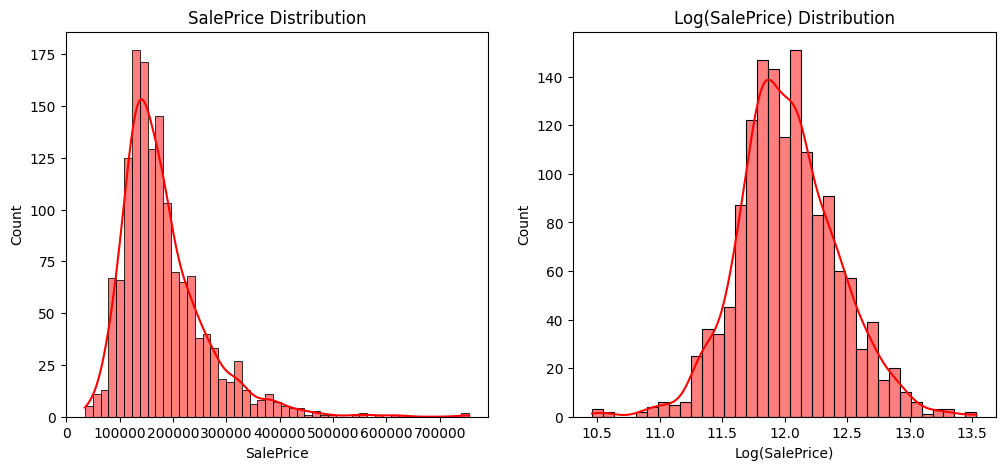

In [4]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
sns.histplot(ax=ax[0], data=train['SalePrice'], kde=True, color='red')#, stat='density')
sns.histplot(ax=ax[1], data=np.log(1+train['SalePrice']), kde=True, color='red')#, stat='density')
ax[0].set_title('SalePrice Distribution')
ax[1].set_title('Log(SalePrice) Distribution')
ax[1].set_xlabel('Log(SalePrice)')
#ax[0].legend()
#ax[1].legend()
plt.show()

In [5]:
train.shape
num_cols = train.select_dtypes(include='number').columns.tolist(), 
cat_cols = train.select_dtypes(include=['category', 'object']).columns.tolist()
num_cols, cat_cols

((['Id',
   'MSSubClass',
   'LotFrontage',
   'LotArea',
   'OverallQual',
   'OverallCond',
   'YearBuilt',
   'YearRemodAdd',
   'MasVnrArea',
   'BsmtFinSF1',
   'BsmtFinSF2',
   'BsmtUnfSF',
   'TotalBsmtSF',
   '1stFlrSF',
   '2ndFlrSF',
   'LowQualFinSF',
   'GrLivArea',
   'BsmtFullBath',
   'BsmtHalfBath',
   'FullBath',
   'HalfBath',
   'BedroomAbvGr',
   'KitchenAbvGr',
   'TotRmsAbvGrd',
   'Fireplaces',
   'GarageYrBlt',
   'GarageCars',
   'GarageArea',
   'WoodDeckSF',
   'OpenPorchSF',
   'EnclosedPorch',
   '3SsnPorch',
   'ScreenPorch',
   'PoolArea',
   'MiscVal',
   'MoSold',
   'YrSold',
   'SalePrice'],),
 ['MSZoning',
  'Street',
  'Alley',
  'LotShape',
  'LandContour',
  'Utilities',
  'LotConfig',
  'LandSlope',
  'Neighborhood',
  'Condition1',
  'Condition2',
  'BldgType',
  'HouseStyle',
  'RoofStyle',
  'RoofMatl',
  'Exterior1st',
  'Exterior2nd',
  'MasVnrType',
  'ExterQual',
  'ExterCond',
  'Foundation',
  'BsmtQual',
  'BsmtCond',
  'BsmtExposure',


In [6]:
with pd.option_context('display.max_rows', None):
    print(train['LotShape'].value_counts(dropna=False))

LotShape
Reg    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64


In [7]:
idx = train.isna().sum().index
Nans_df = pd.DataFrame(index=idx, columns=['train', 'test'])
Nans_df['train'] = train.isna().sum()/train.shape[0]
Nans_df['test'] = test.isna().sum()/test.shape[0]
with pd.option_context('display.max_rows', None):
    print(Nans_df)

                  train      test
Id             0.000000  0.000000
MSSubClass     0.000000  0.000000
MSZoning       0.000000  0.002742
LotFrontage    0.177397  0.155586
LotArea        0.000000  0.000000
Street         0.000000  0.000000
Alley          0.937671  0.926662
LotShape       0.000000  0.000000
LandContour    0.000000  0.000000
Utilities      0.000000  0.001371
LotConfig      0.000000  0.000000
LandSlope      0.000000  0.000000
Neighborhood   0.000000  0.000000
Condition1     0.000000  0.000000
Condition2     0.000000  0.000000
BldgType       0.000000  0.000000
HouseStyle     0.000000  0.000000
OverallQual    0.000000  0.000000
OverallCond    0.000000  0.000000
YearBuilt      0.000000  0.000000
YearRemodAdd   0.000000  0.000000
RoofStyle      0.000000  0.000000
RoofMatl       0.000000  0.000000
Exterior1st    0.000000  0.000685
Exterior2nd    0.000000  0.000685
MasVnrType     0.597260  0.612748
MasVnrArea     0.005479  0.010281
ExterQual      0.000000  0.000000
ExterCond     

In [8]:
#X_train = train.drop(columns=['SalePrice'])
#y_train = train['SalePrice']

train['SalePrice'] = np.log1p(train['SalePrice'])
data_splitter = DataSplitter("SalePrice", test_size=0.2)
X_train, X_test, y_train, y_test = data_splitter.split(train)

transformer = Transformer(config_path=config_path)
preprocessor = PreProcessor(df=X_train, config_path=config_path)
preprocessor = preprocessor.build()
model_collection = ModelCollection()
model = model_collection.get('OLS')
pipeline = PipelineBuilder(transformer=transformer, preprocessor=preprocessor, model=model)
pipeline = pipeline.build()
pipeline.fit(X_train, y_train)

pred = pd.Series(pipeline.predict(X_test), index=y_test.index)

results = pd.DataFrame({'y_test': y_test.values, 'pred': pred.values.astype(int)})
results['Diff%'] = 100 * abs((results['y_test']-results['pred']) / results['y_test'])
print(results.describe())

# Evaluation through cross validation
n_folds = 5
cv = CrossValidation(n_folds, pipeline)
X, y = train.drop(columns=['SalePrice']), train['SalePrice']
score_stats = cv.evaluate(X,y)
print(score_stats)

#X_train_transformed = pipeline.named_steps["features"].transform(X_train)
X_train_transformed = pipeline.named_steps["preprocess"].transform(X_train)#X_train_transformed)
feature_names = pipeline.named_steps["preprocess"].get_feature_names_out()
X_train_df = pd.DataFrame(X_train_transformed.toarray() if hasattr(X_train_transformed, "toarray") else X_train_transformed,
    columns=feature_names, index=X_train.index)
X_train_df.head(20)

           y_test        pred       Diff%
count  292.000000  292.000000  292.000000
mean    11.997654   11.465753    4.498972
std      0.432727    0.539369    2.547491
min     10.471978   10.000000    0.007482
25%     11.751950   11.000000    2.075960
50%     11.945687   11.000000    4.951138
75%     12.250929   12.000000    6.778059
max     13.534474   13.000000   11.251881
{'mean_mse': np.float64(0.1387951093028066), 'std_mse': np.float64(0.03109330060020327)}


,num__1stFlrSF,num__Id,num__MasVnrArea,num__MSSubClass,num__GarageArea,num__MiscVal,num__BsmtUnfSF,num__2ndFlrSF,num__YrSold,num__LowQualFinSF,...,na_as_none__GarageType_Basment,na_as_none__GarageType_BuiltIn,na_as_none__GarageType_CarPort,na_as_none__GarageType_Detchd,na_as_none__GarageType_None,na_as_none__MasVnrType_BrkCmn,na_as_none__MasVnrType_BrkFace,na_as_none__MasVnrType_None,na_as_none__MasVnrType_Stone,na_as_zero__GarageYrBlt
254,4122.211104,-1.119284,-0.597889,-0.866764,-0.863837,-0.09274,-0.400282,-0.801923,1.650065,-0.118999,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.192392
1066,2497.909390,0.790464,-0.597889,0.074110,-0.456264,-0.09274,0.511920,0.955088,0.893677,-0.118999,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.272225
638,2488.447439,-0.216152,-0.597889,-0.631546,-2.257169,-0.09274,0.505196,-0.801923,0.137290,-0.118999,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,-4.147410
799,3071.934462,0.162505,0.861522,-0.161109,-1.119755,-0.09274,-0.915776,0.989227,-0.619098,-0.118999,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.152476
380,3213.863738,-0.822944,-0.597889,-0.161109,-0.797488,-0.09274,0.532091,0.711564,1.650065,-0.118999,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.119212
303,2797.537862,-1.004041,-0.597889,-0.866764,0.358883,-0.09274,-1.278864,-0.801923,-1.375486,-0.118999,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.232309
86,2135.201241,-1.514404,-0.597889,0.074110,-0.361479,-0.09274,0.254172,1.191783,0.893677,-0.118999,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.298836
1385,2488.447439,1.540722,-0.597889,-0.161109,-1.119755,-0.09274,-1.142146,0.012857,1.650065,-0.118999,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.114777
265,4462.841366,-1.093413,0.618287,-0.866764,0.472624,-0.09274,0.079352,-0.801923,0.137290,-0.118999,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.245614
793,4696.236175,0.148394,0.212895,-0.866764,-0.010777,-0.09274,2.074093,-0.801923,-0.619098,-0.118999,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.303271


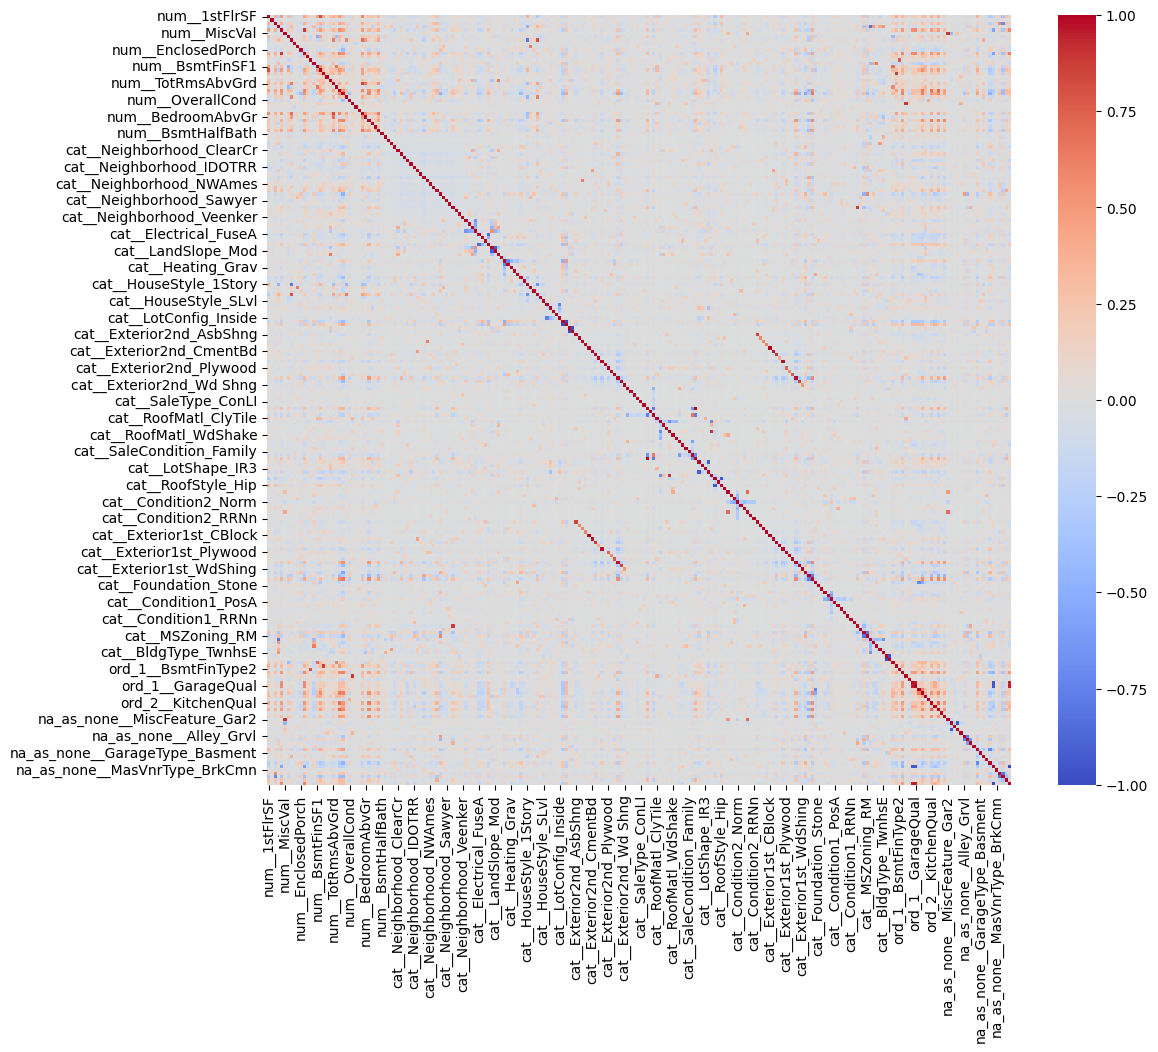

In [9]:
plt.figure(figsize=(12, 10))
sns.heatmap(X_train_df.corr(), cmap="coolwarm", center=0)
plt.show()

In [10]:
corr_with_target = X_train_df.corrwith(y_train)
with pd.option_context('display.max_rows', None):
    print(corr_with_target.sort_values(ascending=False))
    print(len(corr_with_target))

num__OverallQual                  0.807946
num__GrLivArea                    0.689012
num__GarageCars                   0.684451
ord_2__KitchenQual                0.667939
ord_2__ExterQual                  0.660159
num__GarageArea                   0.654520
ord_1__BsmtQual                   0.622365
ord_1__GarageFinish               0.607353
num__TotalBsmtSF                  0.597214
num__FullBath                     0.583747
num__1stFlrSF                     0.580948
num__YearBuilt                    0.576725
num__YearRemodAdd                 0.562152
ord_1__FireplaceQu                0.541509
num__TotRmsAbvGrd                 0.520082
cat__Foundation_PConc             0.518922
ord_2__HeatingQC                  0.484609
num__Fireplaces                   0.481761
num__MasVnrArea                   0.419978
na_as_none__GarageType_Attchd     0.405525
ord_1__GarageQual                 0.376042
na_as_zero__GarageYrBlt           0.367147
ord_1__GarageCond                 0.366829
cat__Centra

In [11]:
# Skewness of raw features
column_skewness = X_train_df.skew(numeric_only=True)
with pd.option_context('display.max_rows', None):
    print(column_skewness.sort_values(ascending=False))

cat__Condition2_RRAn              34.176015
cat__Heating_Floor                34.176015
cat__Exterior1st_CBlock           34.176015
cat__Condition2_RRAe              34.176015
cat__Exterior2nd_Other            34.176015
cat__Exterior2nd_CBlock           34.176015
cat__Condition2_RRNn              34.176015
cat__Condition1_RRNe              34.176015
cat__Exterior1st_AsphShn          34.176015
cat__Utilities_NoSeWa             34.176015
na_as_none__MiscFeature_TenC      34.176015
cat__RoofMatl_ClyTile             34.176015
cat__Exterior1st_Stone            34.176015
cat__Exterior1st_ImStucc          34.176015
cat__Neighborhood_Blueste         34.176015
cat__Condition2_PosA              34.176015
cat__RoofMatl_Metal               34.176015
cat__RoofMatl_Roll                34.176015
cat__RoofStyle_Shed               24.134984
cat__Exterior1st_BrkComm          24.134984
cat__SaleType_Con                 24.134984
na_as_none__MiscFeature_Gar2      24.134984
na_as_none__MiscFeature_Othr    

In [12]:
X_train_df[['cat__Utilities_AllPub', 'cat__Street_Pave', 'num__MiscVal', 'num__LotArea']].value_counts()

cat__Utilities_AllPub  cat__Street_Pave  num__MiscVal  num__LotArea
1.0                    1.0               -0.092740     18566.493900    23
                                                       13920.455533    18
                                                       11597.436350    14
                                                       16243.474716    11
                                                       17404.984308    10
                                                                       ..
                                          3.525186     32295.537272     1
                                          4.429667     17486.289979     1
                                          6.238630     10823.096623     1
                                          14.921653    36550.534076     1
                                          0.811741     20155.826191     1
Name: count, Length: 905, dtype: int64

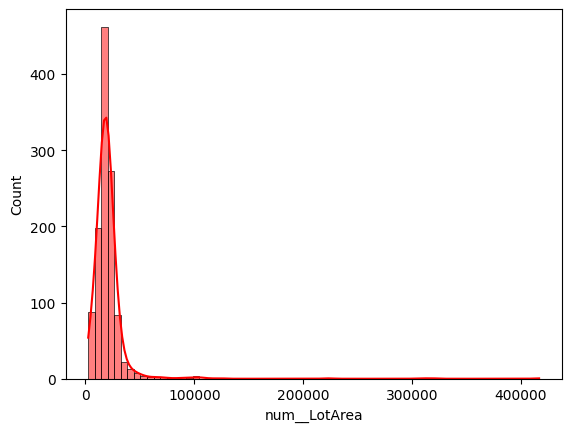

In [16]:
sns.histplot(data=X_train_df['num__LotArea'], kde=True, color='red')
#plt.xlim(min(X_train_df['num__LotArea'])-0.2, 6) 
plt.show()

In [14]:
# We'll run a linear regression of target against raw feature, then against log feature, and compare the CVs
# If after applying log to the feature we notice an improvement in CV score, this is a signal that the 
# feature might be log transformed

column_skewness = X_train_df.skew(numeric_only=True)
num_cols = [col for col in list(X_train_df.columns) if col[:3]=="num"]
num_cols_names = [col[5:] for col in num_cols]
logX_train = X_train.copy()
logX_train[num_cols_names] = np.log1p(X_train[num_cols_names])

logpreprocessor = PreProcessor(df=logX_train, config_path=config_path)
logpreprocessor = logpreprocessor.build()
logpreprocessor.fit(logX_train, y_train)

logX_train_transformed = logpreprocessor.transform(logX_train)
feature_names = logpreprocessor.get_feature_names_out()
logX_train_df = pd.DataFrame(logX_train_transformed.toarray() if hasattr(logX_train_transformed, "toarray") else logX_train_transformed,
    columns=feature_names, index=logX_train.index)

cv_scores, y = {}, y_train
for col in num_cols:
    if(abs(column_skewness[col]) > 1):
        X = X_train_df[[col]].copy()
        score_raw = cross_val_score(LinearRegression(), X, y, cv=5, scoring="neg_root_mean_squared_error")
        score_raw_mean, score_raw_std = float(int(1000*score_raw.mean()))/1000, float(int(1000*score_raw.std()))/1000 
        X_log = logX_train_df[[col]].copy()
        score_log = cross_val_score(LinearRegression(), X_log, y, cv=5, scoring="neg_root_mean_squared_error")
        score_log_mean, score_log_std = float(int(1000*score_log.mean()))/1000, float(int(1000*score_log.std()))/1000 
        skewness = float(int(1000*column_skewness[col]))/1000
        cv_scores[col] = [skewness, score_raw_mean, score_raw_std, score_log_mean, score_log_std]

cv_scores

{'num__1stFlrSF': [1.422, -0.316, 0.03, -0.313, 0.021],
 'num__MasVnrArea': [2.294, -0.353, 0.027, -0.358, 0.024],
 'num__MSSubClass': [1.438, -0.389, 0.025, -0.39, 0.025],
 'num__MiscVal': [22.053, -0.39, 0.025, -0.389, 0.025],
 'num__LowQualFinSF': [9.199, -0.39, 0.026, -0.389, 0.026],
 'num__EnclosedPorch': [3.163, -0.385, 0.021, -0.38, 0.02],
 'num__WoodDeckSF': [1.587, -0.366, 0.029, -0.363, 0.026],
 'num__BsmtFinSF2': [4.217, -0.39, 0.025, -0.39, 0.025],
 'num__KitchenAbvGr': [4.445, -0.385, 0.026, -0.385, 0.025],
 'num__BsmtFinSF1': [1.862, -0.366, 0.028, -0.384, 0.023],
 'num__TotalBsmtSF': [1.723, -0.312, 0.036, -0.361, 0.024],
 'num__ScreenPorch': [4.09, -0.387, 0.024, -0.388, 0.025],
 'num__LotArea': [11.958, -0.382, 0.025, -0.356, 0.022],
 'num__PoolArea': [14.396, -0.388, 0.026, -0.388, 0.027],
 'num__3SsnPorch': [9.833, -0.39, 0.025, -0.39, 0.025],
 'num__GrLivArea': [1.425, -0.282, 0.03, -0.269, 0.021],
 'num__OpenPorchSF': [2.331, -0.372, 0.031, -0.346, 0.026],
 'num__B

$\textbf{Candidates for log transform:}$

LotArea(YES), OpenPorchSF(visual insapection -> NO), GrLivArea(YES), 1stFlrSF(YES), LotFrontage(YES)

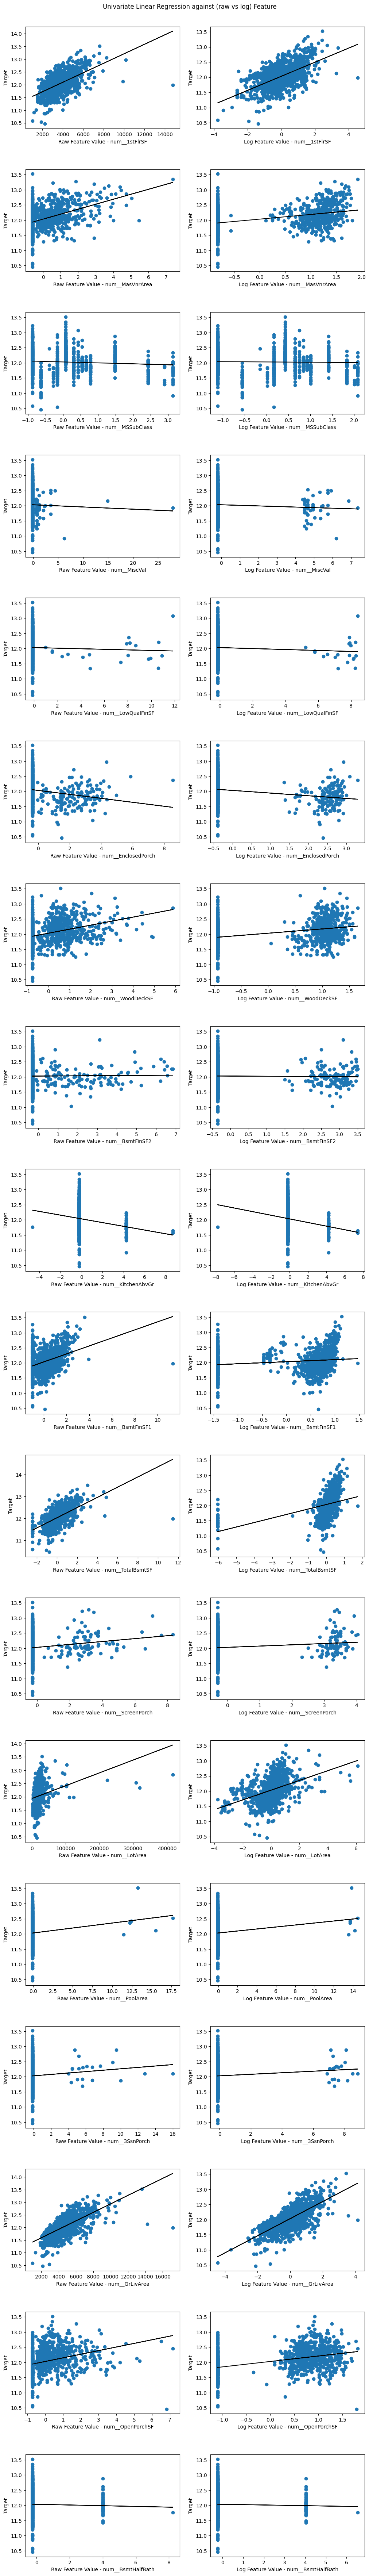

In [15]:
# Checking visually
cols = cv_scores.keys()
fig, ax = plt.subplots(nrows=len(cols), ncols=2, figsize=(12, 5*len(cols)))
for i, col in enumerate(cols):
    x, y = pd.DataFrame({"x": X_train_df[col]}), y_train
    
    ols = LinearRegression()
    ols.fit(x, y)
    ax[i, 0].plot(x, ols.predict(x), color='black')
    ax[i, 0].scatter(x, y)
    ax[i, 0].set_ylabel('Target')
    ax[i, 0].set_xlabel(f'Raw Feature Value - {col}')

    
    ols = LinearRegression()
    x = pd.DataFrame({"x": logX_train_df[col]})
    ols.fit(x, y)
    ax[i, 1].plot(x, ols.predict(x), color='black')
    ax[i, 1].scatter(x, y)
    ax[i, 1].set_ylabel('Target')
    ax[i, 1].set_xlabel(f'Log Feature Value - {col}')

plt.subplots_adjust(hspace=0.4) 
fig.suptitle("Univariate Linear Regression against (raw vs log) Feature", fontsize=12, y=0.887)
plt.show()